# wm_train.ipynb

Entraînement du LeWorldModel (LeWM) sur le dataset gridworld isométrique.

Ce notebook :
- détecte local / Google Colab
- monte Google Drive et clone le repo si besoin
- charge le dataset `.npz` généré par `wm_dataset.ipynb`
- instancie et entraîne le `LeWorldModel` (ViT + Transformer AdaLN + SIGReg)
- sauvegarde le checkpoint sur Drive ou `local_runs/`

**Règle :** ne jamais modifier le code ici. Toujours LOCAL → GIT → COLAB.

## 1. Setup environnement

Détecte local vs Colab, monte Drive, clone le repo.

In [1]:
import sys
import subprocess
import shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    repo_dir = Path("/content/wm_colab")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/Stabadev/wm_colab.git", str(repo_dir)],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull"], check=True)

    # Purge le cache .pyc pour forcer le rechargement du code à jour
    shutil.rmtree(repo_dir / "src" / "__pycache__", ignore_errors=True)
    sys.path.insert(0, str(repo_dir))

    BASE_DIR     = Path("/content/drive/MyDrive/projetColab/wm_colab")
    DATASET_PATH = BASE_DIR / "datasets/dataset_iso_N5_50k.npz"
else:
    sys.path.insert(0, str(Path("..").resolve()))
    BASE_DIR     = Path("../local_runs")
    DATASET_PATH = BASE_DIR / "datasets/dataset_iso_N5_50k.npz"

CHECKPOINT_DIR = BASE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB       = {IN_COLAB}")
print(f"DATASET_PATH   = {DATASET_PATH}")
print(f"CHECKPOINT_DIR = {CHECKPOINT_DIR}")
print(f"Dataset existe : {DATASET_PATH.exists()}")

Mounted at /content/drive
IN_COLAB       = True
DATASET_PATH   = /content/drive/MyDrive/projetColab/wm_colab/datasets/dataset_iso_N5_50k.npz
CHECKPOINT_DIR = /content/drive/MyDrive/projetColab/wm_colab/checkpoints
Dataset existe : True


## 2. Imports

In [2]:
import math
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from src.model import LeWorldModel

print("Imports OK")
print(f"PyTorch {torch.__version__}")

Imports OK
PyTorch 2.10.0+cu128


## 3. Hyperparamètres

Tout est ici. Modifier uniquement cette cellule pour changer la config.

In [3]:
# Architecture
IMG_SIZE        = 128
PATCH_SIZE      = 16
EMBED_DIM       = 192
ENCODER_DEPTH   = 4
PREDICTOR_DEPTH = 2
N_HEADS         = 3
N_ACTIONS       = 4
MLP_RATIO       = 4.0

# SIGReg — lambda élevé pour compenser la simplicité du gridworld
# (papier : 0.1 sur environnements complexes)
SIGREG_M      = 1024
SIGREG_LAMBDA = 10.0

# Training
BATCH_SIZE    = 256     # → 256 sur Colab GPU
N_EPOCHS      = 200
LR            = 3e-4
WEIGHT_DECAY  = 0.01
WARMUP_EPOCHS = 5
SEED          = 42

# Checkpoint
CKPT_NAME = "lewm_vit_50k_v5.pt"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition


## 4. Dataset

Chaque élément = une transition (obs_t, action, obs_t1).

Le modèle reçoit des séquences de longueur T=2 : `obs = [obs_t, obs_t1]`.

In [4]:
class TransitionDataset(Dataset):
    def __init__(self, path):
        d = np.load(path)
        self.obs_t   = d["obs_t"]    # (N, H, W) uint8
        self.obs_t1  = d["obs_t1"]   # (N, H, W) uint8
        self.actions = d["actions"]  # (N,) int64

    def __len__(self):
        return len(self.actions)

    def __getitem__(self, i):
        obs = np.stack([self.obs_t[i], self.obs_t1[i]], axis=0).astype(np.float32) / 255.0
        return torch.from_numpy(obs), torch.tensor(self.actions[i], dtype=torch.long)


dataset = TransitionDataset(DATASET_PATH)
loader  = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0,
)

obs_sample, act_sample = dataset[0]
print(f"Dataset       : {len(dataset):,} transitions")
print(f"obs shape     : {tuple(obs_sample.shape)}  dtype={obs_sample.dtype}")
print(f"action shape  : {tuple(act_sample.shape)}  dtype={act_sample.dtype}")
print(f"Batches/epoch : {len(loader)}")

Dataset       : 50,000 transitions
obs shape     : (2, 128, 128)  dtype=torch.float32
action shape  : ()  dtype=torch.int64
Batches/epoch : 196


## 5. Modèle

In [5]:
model = LeWorldModel(
    img_size        = IMG_SIZE,
    patch_size      = PATCH_SIZE,
    embed_dim       = EMBED_DIM,
    encoder_depth   = ENCODER_DEPTH,
    predictor_depth = PREDICTOR_DEPTH,
    n_heads         = N_HEADS,
    n_actions       = N_ACTIONS,
    mlp_ratio       = MLP_RATIO,
    sigreg_M        = SIGREG_M,
    sigreg_lambda   = SIGREG_LAMBDA,
    stop_gradient   = False,   # formulation pure du papier LeWM
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres : {n_params/1e6:.2f}M")

# Vérification d'un forward pass
with torch.no_grad():
    obs_b, act_b = next(iter(loader))
    loss_test, info_test = model(obs_b.to(DEVICE), act_b.to(DEVICE))
    print(f"Forward OK → total={info_test['total']:.4f}  pred={info_test['pred']:.4f}  sigreg={info_test['sigreg']:.4f}")

Paramètres : 3.03M
Forward OK → total=33.2202  pred=0.3724  sigreg=3.2848


## 6. Optimiseur et scheduler

AdamW avec warmup linéaire puis décroissance cosinus.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, N_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Optimiseur : AdamW  lr={LR}  wd={WEIGHT_DECAY}")
print(f"Scheduler  : warmup {WARMUP_EPOCHS} epochs → cosine decay")

Optimiseur : AdamW  lr=0.0003  wd=0.01
Scheduler  : warmup 5 epochs → cosine decay


## 7. Boucle d'entraînement

In [7]:
history = {"total": [], "pred": [], "sigreg": []}

t0 = time.time()

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    run_total = run_pred = run_sig = 0.0

    for obs_b, act_b in tqdm(loader, desc=f"Epoch {epoch:03d}/{N_EPOCHS}", leave=False):
        obs_b = obs_b.to(DEVICE)
        act_b = act_b.to(DEVICE)

        loss, info = model(obs_b, act_b)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_total += info["total"]
        run_pred  += info["pred"]
        run_sig   += info["sigreg"]

    scheduler.step()

    n = len(loader)
    history["total"].append(run_total / n)
    history["pred"].append(run_pred / n)
    history["sigreg"].append(run_sig / n)

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:03d} | "
        f"total={history['total'][-1]:.4f}  "
        f"pred={history['pred'][-1]:.4f}  "
        f"sigreg={history['sigreg'][-1]:.4f}  "
        f"lr={lr_now:.2e}"
    )

elapsed = time.time() - t0
print(f"\nEntraînement terminé en {elapsed:.1f}s ({elapsed/60:.1f} min)")

Epoch 001/200:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 001 | total=9.2048  pred=0.0186  sigreg=0.9186  lr=1.20e-04


Epoch 002/200:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 002 | total=8.4935  pred=0.0018  sigreg=0.8492  lr=1.80e-04


Epoch 003/200:   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 198 | total=0.0763  pred=0.0001  sigreg=0.0076  lr=7.79e-08


Epoch 199/200:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 199 | total=0.0743  pred=0.0001  sigreg=0.0074  lr=1.95e-08


Epoch 200/200:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 200 | total=0.0708  pred=0.0001  sigreg=0.0071  lr=0.00e+00

Entraînement terminé en 917.5s (15.3 min)


## 8. Courbes de loss

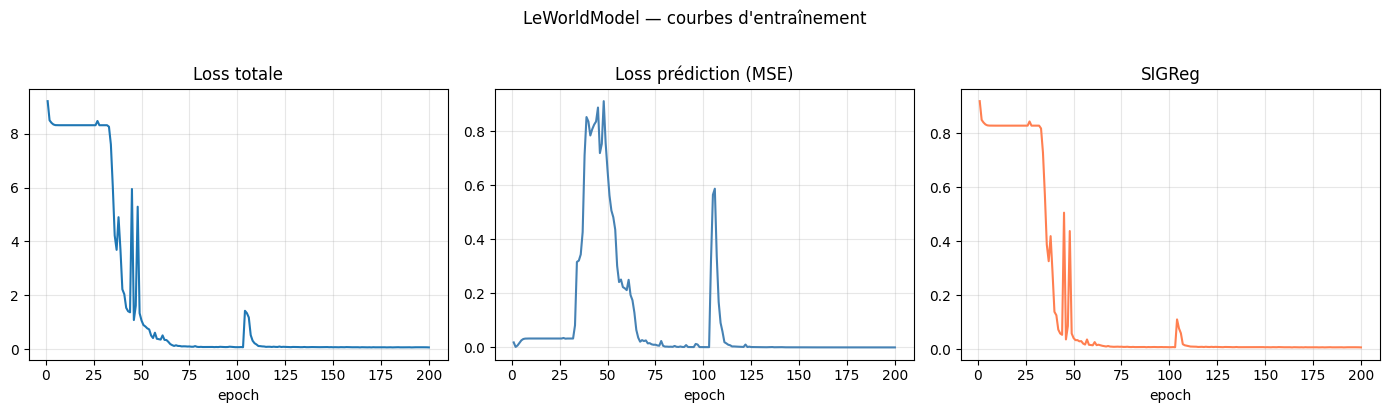

In [8]:
epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, history["total"])
axes[0].set_title("Loss totale")
axes[0].set_xlabel("epoch")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["pred"], color="steelblue")
axes[1].set_title("Loss prédiction (MSE)")
axes[1].set_xlabel("epoch")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["sigreg"], color="coral")
axes[2].set_title("SIGReg")
axes[2].set_xlabel("epoch")
axes[2].grid(True, alpha=0.3)

plt.suptitle("LeWorldModel — courbes d'entraînement", y=1.02)
plt.tight_layout()
plt.show()

## 9. Diagnostic anti-collapse

Vérifie que les embeddings ne se sont pas effondrés (std proche de 0 = collapse).

In [9]:
model.eval()
all_embs = []

with torch.no_grad():
    for obs_b, act_b in loader:
        emb = model.encode(obs_b.to(DEVICE))  # (B, T, D)
        all_embs.append(emb[:, 0].cpu())
        if len(all_embs) >= 10:
            break

all_embs = torch.cat(all_embs, dim=0)  # (N_samples, D)

mean_std  = all_embs.std(dim=0).mean().item()
mean_mean = all_embs.mean(dim=0).abs().mean().item()

print(f"std moyenne par dimension  : {mean_std:.4f}  (> 0.1 = OK, proche 0 = collapse)")
print(f"|mean| moyen par dimension : {mean_mean:.4f}  (proche 0 = OK pour SIGReg)")

if mean_std < 0.05:
    print("ATTENTION : std très faible — collapse possible. Augmenter SIGREG_LAMBDA.")
else:
    print("Représentations diversifiées.")

std moyenne par dimension  : 0.9558  (> 0.1 = OK, proche 0 = collapse)
|mean| moyen par dimension : 0.0167  (proche 0 = OK pour SIGReg)
Représentations diversifiées.


## 10. Sauvegarde du checkpoint

In [10]:
import time as _time

ckpt_path = CHECKPOINT_DIR / CKPT_NAME

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "history": history,
        "config": {
            "img_size"        : IMG_SIZE,
            "patch_size"      : PATCH_SIZE,
            "embed_dim"       : EMBED_DIM,
            "encoder_depth"   : ENCODER_DEPTH,
            "predictor_depth" : PREDICTOR_DEPTH,
            "n_heads"         : N_HEADS,
            "n_actions"       : N_ACTIONS,
            "sigreg_M"        : SIGREG_M,
            "sigreg_lambda"   : SIGREG_LAMBDA,
            "n_epochs"        : N_EPOCHS,
            "batch_size"      : BATCH_SIZE,
            "lr"              : LR,
        },
        "timestamp": _time.strftime("%Y-%m-%d %H:%M:%S"),
    },
    ckpt_path,
)

size_mb = ckpt_path.stat().st_size / 1e6
print(f"Checkpoint sauvegardé : {ckpt_path}")
print(f"Taille : {size_mb:.2f} Mo")

Checkpoint sauvegardé : /content/drive/MyDrive/projetColab/wm_colab/checkpoints/lewm_vit_50k_v5.pt
Taille : 12.93 Mo


## 11. Résumé final

In [11]:
print("Résumé")
print(f"  Dataset     : {len(dataset):,} transitions")
print(f"  Modèle      : {n_params/1e6:.2f}M paramètres")
print(f"  Entraînement: {N_EPOCHS} epochs sur {DEVICE}")
print(f"  Loss finale : total={history['total'][-1]:.4f}  pred={history['pred'][-1]:.4f}  sigreg={history['sigreg'][-1]:.4f}")
print(f"  Checkpoint  : {ckpt_path}")

Résumé
  Dataset     : 50,000 transitions
  Modèle      : 3.03M paramètres
  Entraînement: 200 epochs sur cuda
  Loss finale : total=0.0708  pred=0.0001  sigreg=0.0071
  Checkpoint  : /content/drive/MyDrive/projetColab/wm_colab/checkpoints/lewm_vit_50k_v5.pt
